In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import ee
from skimage.transform import resize

from dataVisu_engine.texture import *
#from dataVisu_engine.utils import *
from dataVisu_engine.GEE_helpers import *
from utils.config import *

# Authenticate and initialize Earth Engine
ee.Authenticate()
ee.Initialize(project='seasonScapes-master')    # create an own Google Earth Engine project

In [ ]:
# Configurations
config = {
    'save_path' : 'data/EarthEngine/',
    'save_fName': 'test',
    'dem_min_m' : 0,   # DEM height model min in meters
    'dem_max_m' : 4500,    # DEM height model max in meters
    'dem_save_mode': 'L',    # I;16 (16bit raw), L (8bit to 0-255)
    'dem_opacity' : 0.8,   # DEM height model opacity
    'land_min' : 0.0,  # LAND threshold min
    'land_max' : 0.6,  # LAND threshold max
    'land_min_ui' : 0, # LAND threshold min for uint8
    'land_max_ui' : 190, # LAND threshold max for uint8
    'land_gamma' : 1.2,    # LAND gamma correction
    'land_cloud_fill_max' : 10, # CLOUD fill max
    'land_sun_elev' : 30,
    'dem_model' : 'NASA30m',  # SRTM90m, ALOS30m, NASA30m
    'land_model' : 'swissTopo10cm',   # Landsat30m, Sentinel10m, SkySat80cm, swissTopo10cm
    'pxScale' : 60,  # One pixel in meters
    'color_correction' : False,
    'aoi' : ee.Geometry.Polygon([[[7.6, 46.85], [7.6, 46.4], [8.35, 46.4], [8.35, 46.85]]], None, False), # all Bernese highland
    'pathMetadata' : 'configs/Livecams-Masterarbeit-Timo-Kleger.csv',
}

In [3]:
# First impression
# LAND
if config['land_model'] == 'Landsat30m':
    land = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterDate('2023-07-01', '2023-11-11')
        .filter(ee.Filter.lt('CLOUD_COVER', config['land_cloud_fill_max']))
        .filter(ee.Filter.gt('SUN_ELEVATION', config['land_sun_elev']))
    )
    land = land.map(apply_scale_factors)
    land_visu = {
        'min': config['land_min'],
        'max': config['land_max'],
        'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
        'gamma': config['land_gamma'],
    }
elif config['land_model'] == 'Sentinel10m':
    land = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate('2024-01-01', '2024-10-12')
        # pre-filter to get less cloudy granules
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', config['land_cloud_fill_max']))
        .map(maskS2clouds)
        #.limit(1000)
        #.filterBounds(AOI)
    )        
    land_visu = {
        'min': config['land_min'],
        'max': config['land_max'],
        'bands': ['B4', 'B3', 'B2'],
        'gamma': config['land_gamma'],
    }
elif config['land_model'] == 'SkySat80cm':
    land = (
        ee.ImageCollection('SKYSAT/GEN-A/PUBLIC/ORTHO/RGB')
        #.filterDate('2023-01-01', '2023-12-31')
    ).select(['R', 'G', 'B'])
    land_visu = {
        'min': config['land_min_ui'],
        'max': config['land_max_ui'],
    }
elif config['land_model'] == 'swissTopo10cm':
    land = ee.Image('Switzerland/SWISSIMAGE/orthos/10cm/2018').select(['R', 'G', 'B'])
    land_visu = None

# DEM
if config['dem_model'] == 'SRTM90m':
    elevation = ee.Image('CGIAR/SRTM90_V4').select('elevation')
elif config['dem_model'] == 'ALOS30m':
    elevationCol = ee.ImageCollection('JAXA/ALOS/AW3D30/V3_2').select('DSM')
    elevation = elevationCol.mean()
elif config['dem_model'] == 'NASA30m':
    elevation = ee.Image('NASA/NASADEM_HGT/001').select('elevation')
slope = ee.Terrain.slope(elevation)
dem_visu = {
    'min': config['dem_min_m'],
    'max': config['dem_max_m'],
    'opacity': config['dem_opacity'],
}

# Map
# center = np.array([7.975, 46.553, 10])
# showMap(config, center, land, elevation, land_visu, dem_visu)
# m = geemap.Map()
# m.set_center(7.975, 46.553, 10)
# if config['land_model'] == 'Landsat_30m':
#     m.addLayer(land.mean(), land_visu, 'True Color (432)')
# elif config['land_model'] == 'Sentinel_10m':
#     m.addLayer(land.mean(), land_visu, 'RGB')
# elif config['land_model'] == 'SkySat_80cm':
#     m.addLayer(land.mean(), land_visu, 'RGB')
# elif config['land_model'] == 'swissTopo_10cm':
#     m.addLayer(land, None, 'swissTopo')
# m.addLayer(elevation, dem_visu, 'elevation')
# m

(836, 1393, 1) min/max: 466 4151


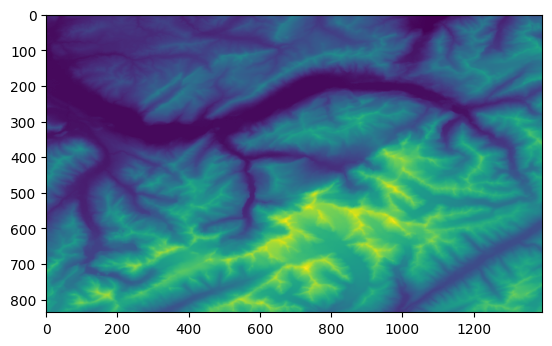

(841, 964, 3) min/max: 0 255


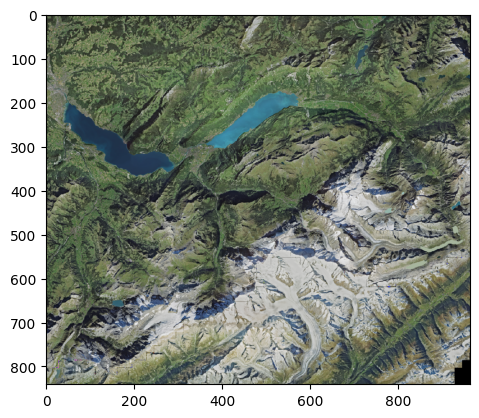

Length metadata: 32


In [ ]:
_, dem_np, _ = processDEM_model(config, plot=True)
_, land_img_np = processLAND_model(config, plot=True)
config.loadCamMetadata(config['pathMetadata'])
metadataRoundshot = config.data_camOrigMetadata

In [ ]:
import cv2

if config['color_correction']:
    land_img = (land_img_np * 255).astype(np.uint8)
    lab = cv2.cvtColor(land_img, cv2.COLOR_RGB2LAB)

    # Split LAB channels
    l_channel, a_channel, b_channel = cv2.split(lab)

    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to the L-channel to enhance contrast
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_channel = clahe.apply(l_channel)

    # Merge the channels back and convert to RGB
    lab = cv2.merge((l_channel, a_channel, b_channel))
    image_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Convert RGB image to HSV (saturation space)
    image_hsv = cv2.cvtColor(image_clahe, cv2.COLOR_RGB2HSV)

    # Split HSV channels
    h_channel, s_channel, v_channel = cv2.split(image_hsv)

    # Increase saturation by a factor (e.g., 1.5 for more saturation)
    saturation_factor = 2.9
    s_channel = np.clip(s_channel * saturation_factor, 0, 255)

    # Ensure all channels have the same dimensions and data types
    h_channel = h_channel.astype(np.uint8)
    s_channel = s_channel.astype(np.uint8)
    v_channel = v_channel.astype(np.uint8)

    # Merge the channels back
    image_hsv_adjusted = cv2.merge([h_channel, s_channel, v_channel])

    # Convert back to RGB
    land_img = cv2.cvtColor(image_hsv_adjusted, cv2.COLOR_HSV2RGB)
    
    # Convert to float32 to scale colors for further adjustment
    land_img = np.float32(land_img) / 255.0

    # Apply color grading by enhancing certain colors
    # You can adjust the values in the matrix to boost specific colors
    color_matrix = np.array([[1.1, 0.1, 0.1], 
                            [0.2, 1.4, 0.1], 
                            [0.1, 0.1, 1.3]])

    # Apply the color matrix to boost certain color channels
    land_img = np.matmul(land_img, color_matrix)

    # Clip values to ensure they stay within [0, 1] and convert back to uint8
    land_img = np.clip(land_img, 0, 1)
    land_img_np = np.power(land_img, config['land_gamma'])

land_img_np = (land_img_np - np.min(land_img_np)) / (np.max(land_img_np) - np.min(land_img_np))

# Ensure dem_np is 2D by squeezing the last dimension
dem_np = dem_np.squeeze()
land_img_np = resize(land_img_np, (dem_np.shape[0], dem_np.shape[1], 3), anti_aliasing=True)

print("DEM shape:", dem_np.shape, "min/max:", np.min(dem_np), np.max(dem_np))
print("LAND shape:", land_img_np.shape, "min/max:", np.min(land_img_np), np.max(land_img_np))

# Extract the x, y coordinates
x = np.linspace(0, dem_np.shape[1], dem_np.shape[1])
y = np.linspace(0, dem_np.shape[0], dem_np.shape[0])
x, y = np.meshgrid(x, y)

# Plot in 3D using Matplotlib
fig = plt.figure(figsize=(10, 20))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, np.flipud(y), dem_np, facecolors=land_img_np, rstride=1, cstride=1, shade=False,)
ax.set_zlim(np.min(dem_np), np.max(dem_np))
ax.set_box_aspect([1, 1, 0.2])  # Makes z-axis less stretched
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Elevation")
plt.show()


In [ ]:
land_img_np = resize(land_img_np, (dem_np.shape[0], dem_np.shape[1], 3), anti_aliasing=True)

I, J, K, tri_color_intensity, pl_colorscale = mesh_data(land_img_np, n_colors=64, n_training_pixels=100000) 

# Extract the x, y coordinates
x = np.linspace(0, dem_np.shape[1], dem_np.shape[1])
y = np.linspace(0, dem_np.shape[0], dem_np.shape[0])
X, Y = np.meshgrid(x, y)

# calculate location in x, y, z coordinate from lat, lon, alt
xCO_min = config['aoi'].getInfo().get('coordinates')[0][0][0]
xCO_max = config['aoi'].getInfo().get('coordinates')[0][1][0]
yCO_min = config['aoi'].getInfo().get('coordinates')[0][0][1]
yCO_max = config['aoi'].getInfo().get('coordinates')[0][2][1]
print("x_min", xCO_min, "x_max", xCO_max, "y_min", yCO_min, "y_max", yCO_max)

print(metadataRoundshot.columns)
metadataRoundshot['x'] = ((metadataRoundshot['GPS long, °E'] - xCO_min) / (xCO_max - xCO_min) * dem_np.shape[1]).round().astype(int)
metadataRoundshot['y'] = ((metadataRoundshot['GPS lat, °N, WGS84'] - yCO_min) / (yCO_max - yCO_min) * dem_np.shape[0]).round().astype(int)

print("min x", metadataRoundshot['x'].min(), "max x", metadataRoundshot['x'].max(), "min y", metadataRoundshot['y'].min(), "max y", metadataRoundshot['y'].max())

#sparse_z_points = np.full_like(dem_np, np.nan)
#sparse_z_points[np.array(metadataRoundshot['y']), np.array(metadataRoundshot['x'])] = np.array(metadataRoundshot[' Altitude (camera), m '])[:, np.newaxis]

# add camera location as additional points

fig = go.Figure(go.Mesh3d(x=X.flatten(), y=np.flipud(Y).flatten(), z=dem_np.flatten(), 
                            i=I, j=J, k=K, intensity=tri_color_intensity, intensitymode="cell", 
                            colorscale=pl_colorscale, showscale=False))
fig.add_scatter3d(connectgaps=False, x=metadataRoundshot['x'], y=metadataRoundshot['y'], z=metadataRoundshot['Altitude (camera), m'],
                                   mode='markers', marker=dict(size=5, color='red', symbol='circle'))


fig.update_layout(scene=dict(
    zaxis=dict(nticks=4, range=[np.min(dem_np), np.max(dem_np)]),
    aspectratio=dict(x=1, y=1, z=0.2),
    xaxis_title='X',
    yaxis_title='Y',
    zaxis_title='Elevation'
))
# Show the figure
fig.show()

# Save the figure as an HTML file
home_path = getHomePath()
save_path = Path(home_path, config['save_path'], f"3d_visu{config['dem_model']}_{config['land_model']}_px{config['pxScale']}m.html")
fig.write_html(save_path.as_posix())

In [ ]:
# Extract the x, y coordinates
x = np.linspace(0, dem_np.shape[1], dem_np.shape[1])
y = np.linspace(0, dem_np.shape[0], dem_np.shape[0])
X, Y = np.meshgrid(x, y)

# calculate location in x, y, z coordinate from lat, lon, alt
xCO_min = config['aoi'].getInfo().get('coordinates')[0][0][0]
xCO_max = config['aoi'].getInfo().get('coordinates')[0][1][0]
yCO_min = config['aoi'].getInfo().get('coordinates')[0][0][1]
yCO_max = config['aoi'].getInfo().get('coordinates')[0][2][1]
print("x_min", xCO_min, "x_max", xCO_max, "y_min", yCO_min, "y_max", yCO_max)

metadataRoundshot['x'] = ((metadataRoundshot['GPS long, °E'] - xCO_min) / (xCO_max - xCO_min) * dem_np.shape[1]).round().astype(int)
metadataRoundshot['y'] = ((metadataRoundshot['GPS lat, °N, WGS84'] - yCO_min) / (yCO_max - yCO_min) * dem_np.shape[0]).round().astype(int)

print("min x", metadataRoundshot['x'].min(), "max x", metadataRoundshot['x'].max(), "min y", metadataRoundshot['y'].min(), "max y", metadataRoundshot['y'].max())

delta_x = 200
metadataRoundshot['delta_y_z'] = delta_x * np.arctan(metadataRoundshot['Field of view (FOV) width, °'] / 2)

fig = go.Figure()
# create 3d meshes
for i, row in metadataRoundshot.iterrows():
    x1 = [row['x'], row['x'] + delta_x, row['x'] + delta_x, row['x'] + delta_x, row['x'] + delta_x]
    y1 = [row['y'], row['y'] + row['delta_y_z'], row['y'] - row['delta_y_z'], row['y'] + row['delta_y_z'], row['y'] - row['delta_y_z']]
    z = [row['Altitude (camera), m'], row['Altitude (camera), m'] - row['delta_y_z'], row['Altitude (camera), m'] - row['delta_y_z'], row['Altitude (camera), m'] + row['delta_y_z'], row['Altitude (camera), m'] + row['delta_y_z']]

    x2 = [row['x'], row['x'] + delta_x, row['x'] - delta_x, row['x'] + delta_x, row['x'] - delta_x]
    y2 = [row['y'], row['y'] + row['delta_y_z'], row['y'] + row['delta_y_z'], row['y'] + row['delta_y_z'], row['y'] + row['delta_y_z']]

    x3 = [row['x'], row['x'] - delta_x, row['x'] - delta_x, row['x'] - delta_x, row['x'] - delta_x]
    y3 = [row['y'], row['y'] - row['delta_y_z'], row['y'] + row['delta_y_z'], row['y'] - row['delta_y_z'], row['y'] + row['delta_y_z']]

    x4 = [row['x'], row['x'] - delta_x, row['x'] + delta_x, row['x'] - delta_x, row['x'] + delta_x]
    y4 = [row['y'], row['y'] - row['delta_y_z'], row['y'] - row['delta_y_z'], row['y'] - row['delta_y_z'], row['y'] - row['delta_y_z']]

    goMesh1 = go.Mesh3d(x=x1, y=y1, z=z, alphahull = 0, color='red', opacity=0.2)
    goMesh2 = go.Mesh3d(x=x2, y=y2, z=z, alphahull = 0, color='#eb8634', opacity=0.2)
    goMesh3 = go.Mesh3d(x=x3, y=y3, z=z, alphahull = 0, color='#edaf34', opacity=0.2)
    goMesh4 = go.Mesh3d(x=x4, y=y4, z=z, alphahull = 0, color='#f2af79', opacity=0.2)
    fig.add_trace(goMesh1)
    fig.add_trace(goMesh2)
    fig.add_trace(goMesh3)
    fig.add_trace(goMesh4)


fig.add_scatter3d(connectgaps=False, x=metadataRoundshot['x'], y=metadataRoundshot['y'], z=metadataRoundshot['Altitude (camera), m'],
                                   mode='markers', marker=dict(size=5, color='red', symbol='circle'))

x_min 7.6 x_max 8.35 y_min 46.4 y_max 46.85
min x 152 max x 1216 min y 270 max y 720


In [ ]:
# color correction
import cv2

print("No color graded", land_img_np.shape, "min/max:", np.min(land_img_np), np.max(land_img_np))
plt.imshow(land_img_np)
plt.show()
  
if config['color_correction']:
    land_img = (land_img_np * 255).astype(np.uint8)
    lab = cv2.cvtColor(land_img, cv2.COLOR_RGB2LAB)

    # Split LAB channels
    l_channel, a_channel, b_channel = cv2.split(lab)

    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to the L-channel to enhance contrast
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_channel = clahe.apply(l_channel)

    # Merge the channels back and convert to RGB
    lab = cv2.merge((l_channel, a_channel, b_channel))
    image_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Convert RGB image to HSV (saturation space)
    image_hsv = cv2.cvtColor(image_clahe, cv2.COLOR_RGB2HSV)

    # Split HSV channels
    h_channel, s_channel, v_channel = cv2.split(image_hsv)

    # Increase saturation by a factor (e.g., 1.5 for more saturation)
    saturation_factor = 2.9
    s_channel = np.clip(s_channel * saturation_factor, 0, 255)

    # Ensure all channels have the same dimensions and data types
    h_channel = h_channel.astype(np.uint8)
    s_channel = s_channel.astype(np.uint8)
    v_channel = v_channel.astype(np.uint8)

    # Merge the channels back
    image_hsv_adjusted = cv2.merge([h_channel, s_channel, v_channel])

    # Convert back to RGB
    land_img = cv2.cvtColor(image_hsv_adjusted, cv2.COLOR_HSV2RGB)
    
    # Convert to float32 to scale colors for further adjustment
    land_img = np.float32(land_img) / 255.0

    # Apply color grading by enhancing certain colors
    # You can adjust the values in the matrix to boost specific colors
    color_matrix = np.array([[1.1, 0.1, 0.1], 
                            [0.2, 1.4, 0.1], 
                            [0.1, 0.1, 1.3]])

    # Apply the color matrix to boost certain color channels
    land_img = np.matmul(land_img, color_matrix)

    # Clip values to ensure they stay within [0, 1] and convert back to uint8
    land_img = np.clip(land_img, 0, 1)
    land_img_np = np.power(land_img, config['land_gamma'])

print("color graded", land_img_np.shape, "min/max:", np.min(land_img_np), np.max(land_img_np))
plt.imshow(land_img_np)
plt.show()